Data loading 




In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# I. Data Collection and Preprocessing
file_path = 'mental_health__dataset1.csv'
data = pd.read_csv(file_path)

# Check dataset info and first few rows
print(data.head())
print(data.info())

   Age  Gender  Technology_Usage_Hours  Social_Media_Usage_Hours  \
0   56    Male                       4                         0   
1   69  Female                       5                         6   
2   46  Female                       1                         0   
3   32  Female                       4                         6   
4   60  Female                       1                         0   

   Screen_Time_Hours  Sleep_Hours  Physical_Activity_Hours  \
0                  3            8                      0.0   
1                  8            5                      2.0   
2                  2            5                      2.0   
3                  4            8                      1.0   
4                  8            8                      0.0   

   Mental_Health_Class  
0       Severe Anxiety  
1     Moderate Anxiety  
2    Severe Depression  
3  Moderate Depression  
4    Severe Depression  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146600 entries, 0 

Handling Classes with One Sample

In [11]:
# Filter out classes with only one sample
class_distribution = data['Mental_Health_Class'].value_counts()
classes_with_one_sample = class_distribution[class_distribution == 1].index
data = data[~data['Mental_Health_Class'].isin(classes_with_one_sample)]

# Check the updated class distribution
print("Class distribution after removing classes with one sample:")
print(data['Mental_Health_Class'].value_counts())


Class distribution after removing classes with one sample:
Mental_Health_Class
Severe Depression      46162
Moderate Depression    31264
Normal/Healthy         30878
Mild Anxiety           20429
Moderate Anxiety        6801
Mild Depression         5807
Severe Anxiety          5258
Name: count, dtype: int64


Handling Missing Values

In [12]:
# Check for missing values and fill them with mean if necessary
data['Physical_Activity_Hours'] = data['Physical_Activity_Hours'].fillna(data['Physical_Activity_Hours'].mean())
# You can also check and handle other columns if there are missing values


Data Preprocessing and Splitting

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assuming the dataset is already loaded into the 'data' variable
file_path = 'mental_health__dataset1.csv'
data = pd.read_csv(file_path)

# Encoding the target variable (Mental_Health_Class)
le = LabelEncoder()
data['Mental_Health_Class'] = le.fit_transform(data['Mental_Health_Class'])

# Split dataset into features (X) and target (y)
X = data[['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']]
y = data['Mental_Health_Class']

# Check the distribution of classes
print("Class distribution:", y.value_counts())

# If there are classes with only one sample, remove them
# Optionally, you can filter out classes that have too few samples (e.g., 1 sample)
min_class_size = 2
class_counts = y.value_counts()
classes_to_remove = class_counts[class_counts < min_class_size].index
data_filtered = data[~data['Mental_Health_Class'].isin(classes_to_remove)]

# Re-split the filtered data
X_filtered = data_filtered[['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']]
y_filtered = data_filtered['Mental_Health_Class']

# Split the filtered dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

# Check the sizes of train and test splits
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")


Class distribution: Mental_Health_Class
6    46162
3    31264
4    30878
0    20429
2     6801
1     5807
5     5258
7        1
Name: count, dtype: int64
Training set size: 117279, Testing set size: 29320


Apply SMOTE

In [14]:
# Apply SMOTE only to the training set (after train-test split)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check class distribution before and after SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())


Class distribution before SMOTE:
Mental_Health_Class
6    36930
3    25011
4    24702
0    16343
2     5441
1     4646
5     4206
Name: count, dtype: int64
Class distribution after SMOTE:
Mental_Health_Class
0    36930
4    36930
3    36930
6    36930
2    36930
5    36930
1    36930
Name: count, dtype: int64


Feature Scaling (Standardization)

In [15]:
# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)  # Use the same scaler for the test set


PCA and LDA for Visualization

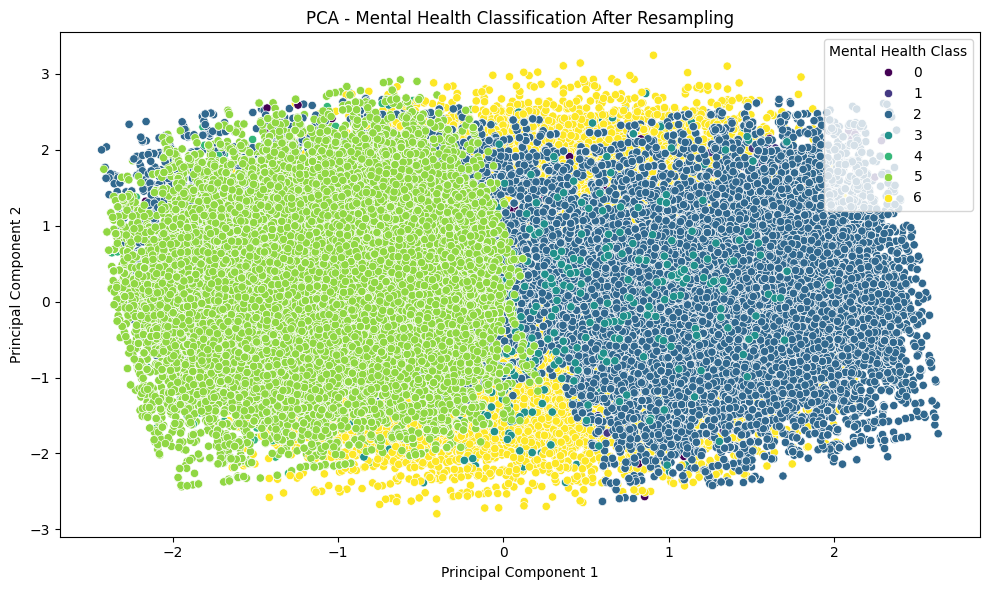

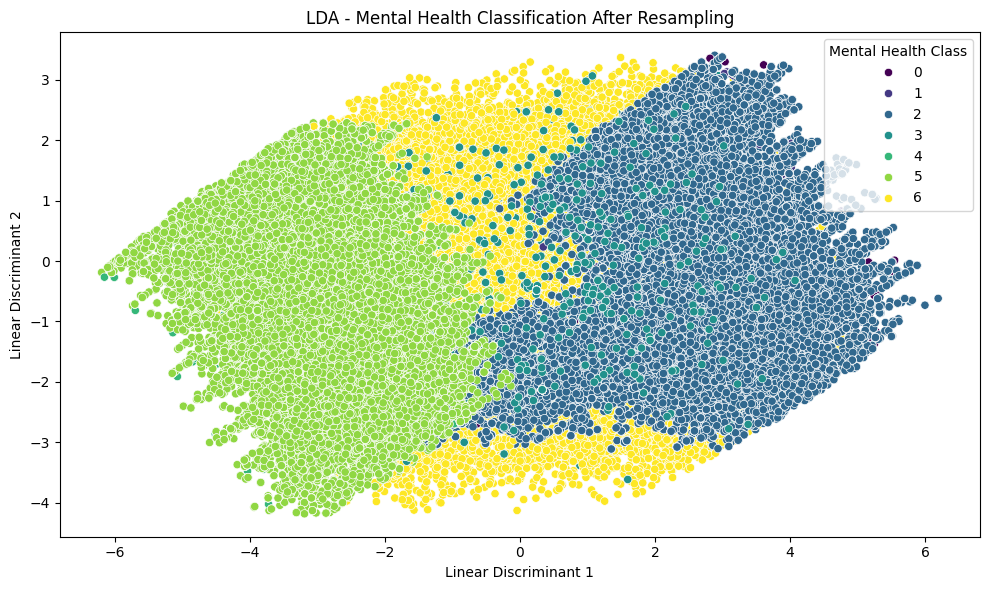

In [16]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")

# PCA Transformation
pca = PCA(n_components=2)  # Set number of components to 2 for visualization
X_pca_train = pca.fit_transform(X_train_scaled)  # Transform training data
X_pca_test = pca.transform(X_test_scaled)       # Transform test data

# LDA Transformation
lda = LDA(n_components=2)  # Set number of components to 2 for visualization
X_lda_train = lda.fit_transform(X_train_scaled, y_train_res)  # Transform training data
X_lda_test = lda.transform(X_test_scaled)                    # Transform test data

# PCA Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_train[:, 0], y=X_pca_train[:, 1], hue=y_train_res, palette='viridis', legend="full")
plt.title("PCA - Mental Health Classification After Resampling")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Mental Health Class", loc="best")
plt.tight_layout()
plt.show()

# LDA Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda_train[:, 0], y=X_lda_train[:, 1], hue=y_train_res, palette='viridis', legend="full")
plt.title("LDA - Mental Health Classification After Resampling")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.legend(title="Mental Health Class", loc="best")
plt.tight_layout()
plt.show()


Model Training and Evaluation

Accuracy after resampling and classification: 98.63%
Cross-validation scores: [0.9897296  0.99023249 0.99044524 0.99156706 0.99176047]
Mean cross-validation score: 99.07%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4086
           1       1.00      0.99      0.99      1161
           2       0.96      0.99      0.98      1360
           3       0.99      0.97      0.98      6253
           4       1.00      0.98      0.99      6176
           5       0.90      0.98      0.94      1052
           6       0.98      1.00      0.99      9232

    accuracy                           0.99     29320
   macro avg       0.98      0.99      0.98     29320
weighted avg       0.99      0.99      0.99     29320

Confusion Matrix:
 [[4036    0   50    0    0    0    0]
 [   0 1152    9    0    0    0    0]
 [   5    5 1350    0    0    0    0]
 [   0    0    0 6082    0    0  171]
 [   0    0    0    0 6067  109    0]

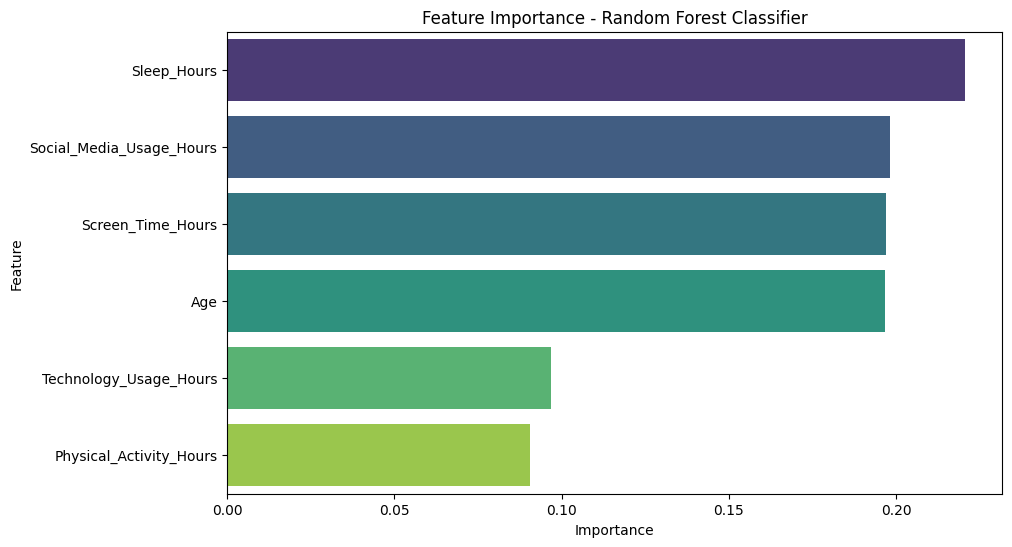

In [17]:
# Train a Random Forest Classifier on the resampled training set
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Calculate and display the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy after resampling and classification: {accuracy * 100:.2f}%")

# Cross-validation for robust evaluation
cv_scores = cross_val_score(classifier, X_train_res, y_train_res, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean() * 100:.2f}%")

# Displaying classification report and confusion matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance (for Random Forest Classifier)
importances = classifier.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualizing Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance - Random Forest Classifier")
plt.show()


Best 4 ML MODELS 

RANDOM FOREST

Training Accuracy: 0.9987
Testing Accuracy: 0.9865
Training Loss: 0.0119
Testing Loss: 0.1980


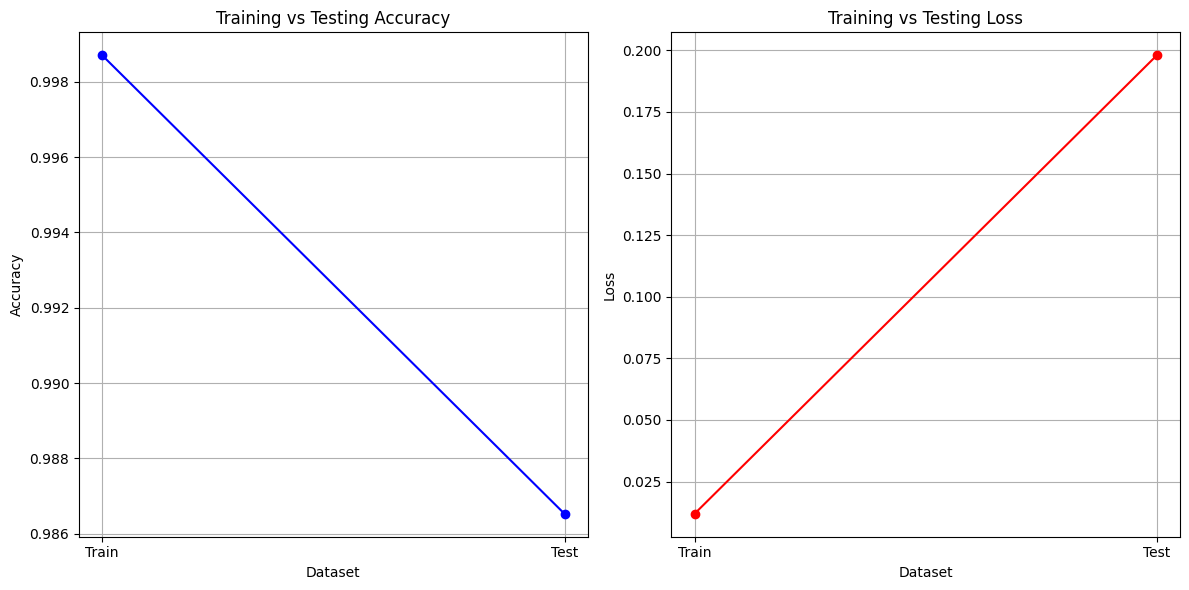

Unique classes in y_train_encoded: [0 1 2 3 4 5 6]
Unique classes in y_test_encoded: [0 1 2 3 4 5 6]
Unique classes in y_pred: [0 1 2 3 4 5 6]
Class distribution in y_train_encoded: [16343  4646  5441 25011 24702  4206 36930]
Class distribution in y_test_encoded: [4086 1161 1360 6253 6176 1052 9232]
Classification Report for Random Forest:
                     precision    recall  f1-score   support

       Mild Anxiety       1.00      0.99      0.99      4086
    Mild Depression       1.00      0.99      1.00      1161
   Moderate Anxiety       0.96      0.99      0.98      1360
Moderate Depression       1.00      0.97      0.98      6253
     Normal/Healthy       1.00      0.98      0.99      6176
     Severe Anxiety       0.90      0.98      0.94      1052
  Severe Depression       0.98      1.00      0.99      9232

           accuracy                           0.99     29320
          macro avg       0.98      0.99      0.98     29320
       weighted avg       0.99      0.99      

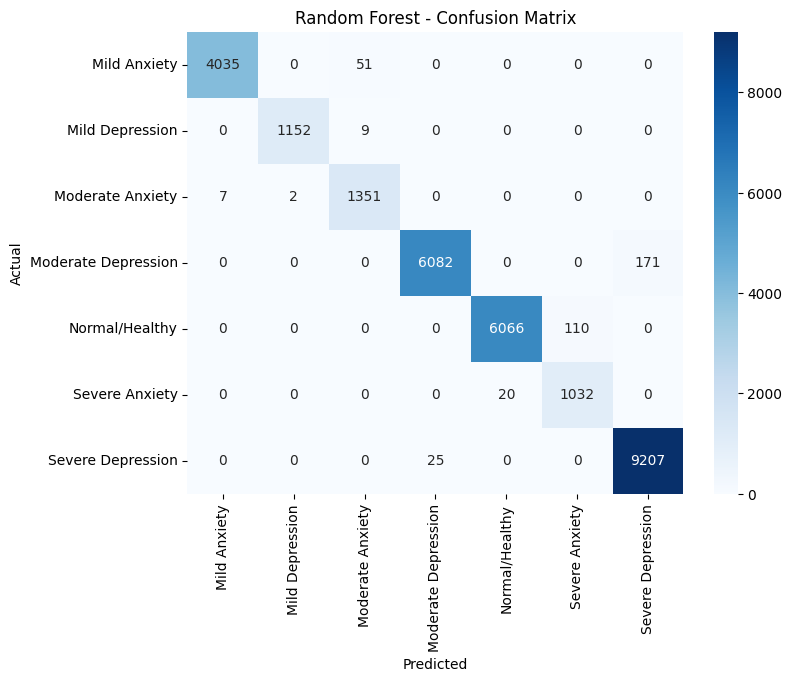

Training ROC AUC Score: 1.0000
Testing ROC AUC Score: 0.9965


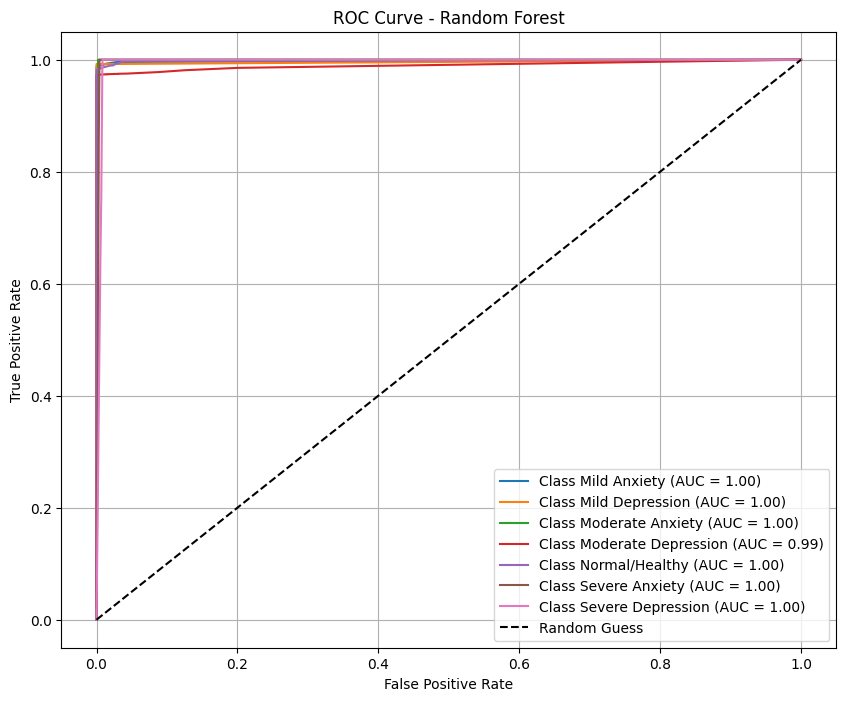

In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, log_loss, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, and y_test are already available

# Encode the target classes
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # Encode the target classes
y_test_encoded = encoder.transform(y_test)

# If the 'Gender' column exists, we encode it
if 'Gender' in X_train.columns:
    X_train['Gender'] = encoder.fit_transform(X_train['Gender'])
    X_test['Gender'] = encoder.transform(X_test['Gender'])

# Scaling the numeric features (excluding categorical columns like 'Gender')
scaler = StandardScaler()
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Only scale numeric columns
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Convert the scaled features back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_columns)

# If the 'Gender' column was encoded, we add it back to the scaled features
if 'Gender' in X_train.columns:
    X_train_scaled['Gender'] = X_train['Gender'].values
    X_test_scaled['Gender'] = X_test['Gender'].values

# Initialize Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Fit the model
model.fit(X_train_scaled, y_train_encoded)

# Make predictions and get probabilities
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_prob = model.predict_proba(X_train_scaled)
y_test_prob = model.predict_proba(X_test_scaled)

# Calculate training and testing metrics
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_loss = log_loss(y_train_encoded, y_train_prob)
test_loss = log_loss(y_test_encoded, y_test_prob)

# Display metrics
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

# Plot training and testing loss and accuracy curves
epochs = ['Train', 'Test']
accuracy_values = [train_accuracy, test_accuracy]
loss_values = [train_loss, test_loss]

plt.figure(figsize=(12, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy_values, marker='o', label='Accuracy', color='blue')
plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_values, marker='o', label='Loss', color='red')
plt.title("Training vs Testing Loss")
plt.xlabel("Dataset")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Check unique values in predictions
print("Unique classes in y_train_encoded:", np.unique(y_train_encoded))
print("Unique classes in y_test_encoded:", np.unique(y_test_encoded))
print("Unique classes in y_pred:", np.unique(y_test_pred))

# Class distribution in train and test sets
print("Class distribution in y_train_encoded:", np.bincount(y_train_encoded))
print("Class distribution in y_test_encoded:", np.bincount(y_test_encoded))

# Target names for classification report
target_names = ['Mild Anxiety', 'Mild Depression', 'Moderate Anxiety', 'Moderate Depression', 
                'Normal/Healthy', 'Severe Anxiety', 'Severe Depression']

# Evaluation
print("Classification Report for Random Forest:")
print(classification_report(y_test_encoded, y_test_pred, target_names=target_names, zero_division=0))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
train_roc_auc = roc_auc_score(y_train_encoded, y_train_prob, multi_class='ovr', average='macro')
test_roc_auc = roc_auc_score(y_test_encoded, y_test_prob, multi_class='ovr', average='macro')
print(f"Training ROC AUC Score: {train_roc_auc:.4f}")
print(f"Testing ROC AUC Score: {test_roc_auc:.4f}")

# Plot AUC Curve
plt.figure(figsize=(10, 8))
for i in range(y_test_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {target_names[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.grid()
plt.show()

In [19]:
import joblib
import h5py

# Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)

# Save as .pkl
joblib.dump(rf_model, "random_forest.pkl")

# Save as .h5
with h5py.File("random_forest_model.h5", "w") as hf:
    hf.create_dataset("model_data", data=joblib.dump(rf_model, 'rf_temp.pkl'))


GRADIENT BOOSTING

Training Accuracy: 0.9869
Testing Accuracy: 0.9875
Training Loss: 0.0574
Testing Loss: 0.0576


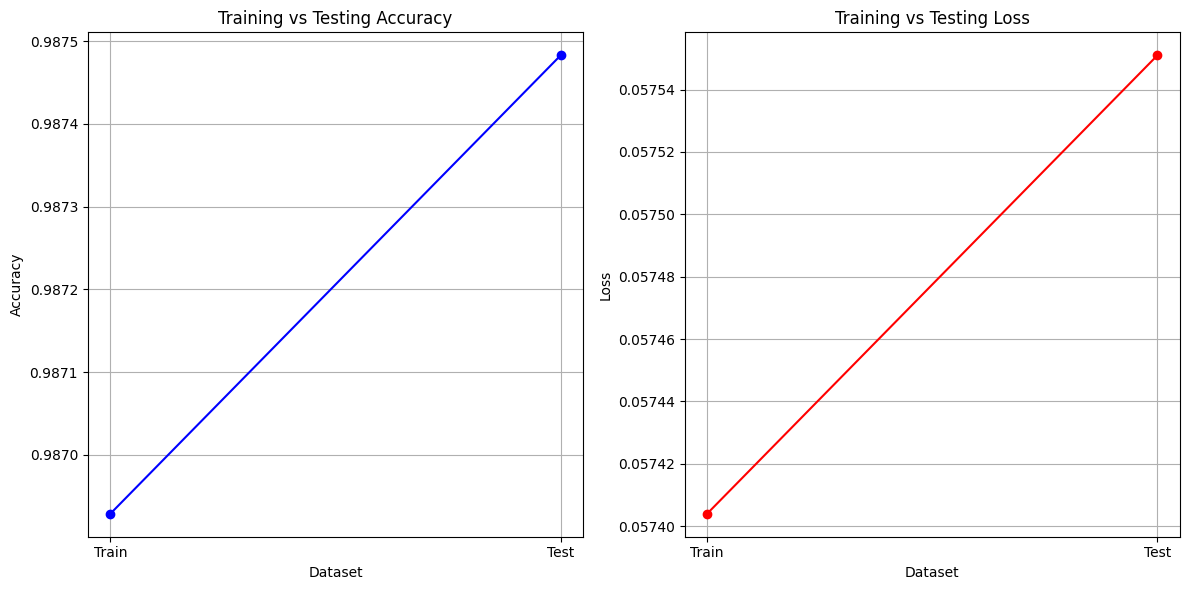

Unique classes in y_train_encoded: [0 1 2 3 4 5 6]
Unique classes in y_test_encoded: [0 1 2 3 4 5 6]
Unique classes in y_pred: [0 1 2 3 4 5 6]
Class distribution in y_train_encoded: [16343  4646  5441 25011 24702  4206 36930]
Class distribution in y_test_encoded: [4086 1161 1360 6253 6176 1052 9232]
Classification Report for Gradient Boosting:
                     precision    recall  f1-score   support

       Mild Anxiety       1.00      0.99      0.99      4086
    Mild Depression       1.00      0.99      0.99      1161
   Moderate Anxiety       0.96      0.99      0.98      1360
Moderate Depression       1.00      0.97      0.99      6253
     Normal/Healthy       1.00      0.98      0.99      6176
     Severe Anxiety       0.90      0.99      0.95      1052
  Severe Depression       0.98      1.00      0.99      9232

           accuracy                           0.99     29320
          macro avg       0.98      0.99      0.98     29320
       weighted avg       0.99      0.99  

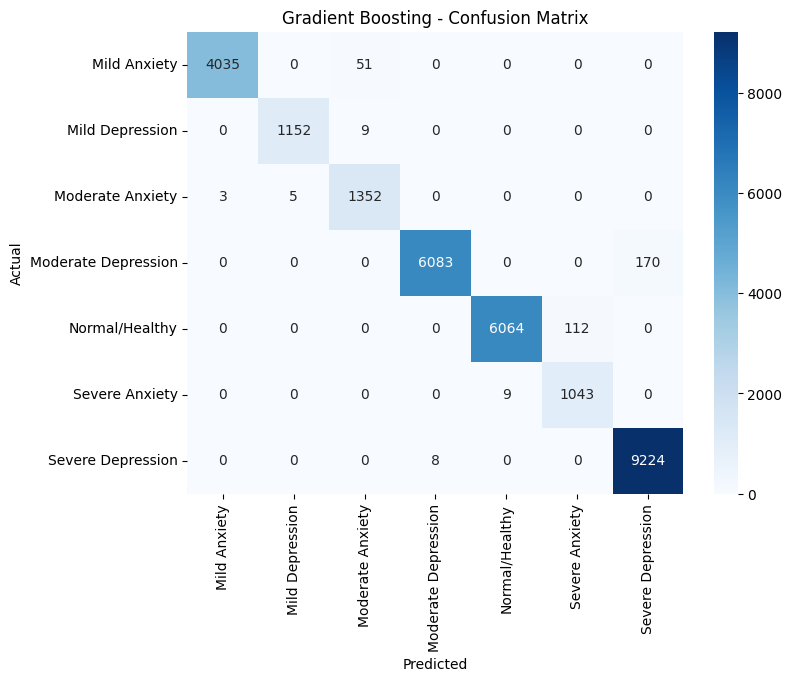

Training ROC AUC Score: 0.9983
Testing ROC AUC Score: 0.9979


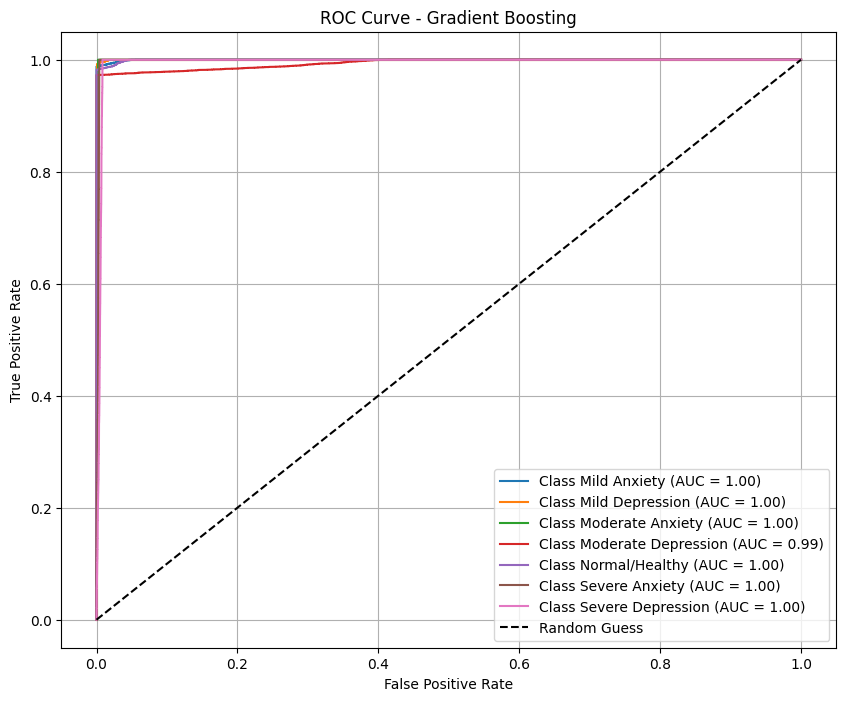

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, log_loss, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, and y_test are already available

# Encode the target classes
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # Encode the target classes
y_test_encoded = encoder.transform(y_test)

# If the 'Gender' column exists, we encode it
if 'Gender' in X_train.columns:
    X_train['Gender'] = encoder.fit_transform(X_train['Gender'])
    X_test['Gender'] = encoder.transform(X_test['Gender'])

# Scaling the numeric features (excluding categorical columns like 'Gender')
scaler = StandardScaler()
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Only scale numeric columns
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Convert the scaled features back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_columns)

# If the 'Gender' column was encoded, we add it back to the scaled features
if 'Gender' in X_train.columns:
    X_train_scaled['Gender'] = X_train['Gender'].values
    X_test_scaled['Gender'] = X_test['Gender'].values

# Initialize Gradient Boosting model
model = GradientBoostingClassifier(random_state=42)

# Fit the model
model.fit(X_train_scaled, y_train_encoded)

# Make predictions and get probabilities
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_prob = model.predict_proba(X_train_scaled)
y_test_prob = model.predict_proba(X_test_scaled)

# Calculate training and testing metrics
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_loss = log_loss(y_train_encoded, y_train_prob)
test_loss = log_loss(y_test_encoded, y_test_prob)

# Display metrics
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

# Plot training and testing loss and accuracy curves
epochs = ['Train', 'Test']
accuracy_values = [train_accuracy, test_accuracy]
loss_values = [train_loss, test_loss]

plt.figure(figsize=(12, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy_values, marker='o', label='Accuracy', color='blue')
plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_values, marker='o', label='Loss', color='red')
plt.title("Training vs Testing Loss")
plt.xlabel("Dataset")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Check unique values in predictions
print("Unique classes in y_train_encoded:", np.unique(y_train_encoded))
print("Unique classes in y_test_encoded:", np.unique(y_test_encoded))
print("Unique classes in y_pred:", np.unique(y_test_pred))

# Class distribution in train and test sets
print("Class distribution in y_train_encoded:", np.bincount(y_train_encoded))
print("Class distribution in y_test_encoded:", np.bincount(y_test_encoded))

# Target names for classification report
target_names = ['Mild Anxiety', 'Mild Depression', 'Moderate Anxiety', 'Moderate Depression', 
                'Normal/Healthy', 'Severe Anxiety', 'Severe Depression']

# Evaluation
print("Classification Report for Gradient Boosting:")
print(classification_report(y_test_encoded, y_test_pred, target_names=target_names, zero_division=0))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
train_roc_auc = roc_auc_score(y_train_encoded, y_train_prob, multi_class='ovr', average='macro')
test_roc_auc = roc_auc_score(y_test_encoded, y_test_prob, multi_class='ovr', average='macro')
print(f"Training ROC AUC Score: {train_roc_auc:.4f}")
print(f"Testing ROC AUC Score: {test_roc_auc:.4f}")

# Plot AUC Curve
plt.figure(figsize=(10, 8))
for i in range(y_test_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {target_names[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.grid()
plt.show()


In [21]:
# Train the Gradient Boosting model
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_scaled, y_train)

# Save as .pkl
joblib.dump(gb_model, "gradient_boosting.pkl")

# Save as .h5
with h5py.File("gradient_boosting_model.h5", "w") as hf:
    hf.create_dataset("model_data", data=joblib.dump(gb_model, 'gb_temp.pkl'))
import xgboost as xgb

# Train the XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_scaled, y_train)

# Save as .pkl
joblib.dump(xgb_model, "xgboost.pkl")

# Save as .h5
with h5py.File("xgboost_model.h5", "w") as hf:
    hf.create_dataset("model_data", data=joblib.dump(xgb_model, 'xgb_temp.pkl'))








XGBoost

Training Accuracy: 0.9891
Testing Accuracy: 0.9878
Training Loss: 0.0310
Testing Loss: 0.0600


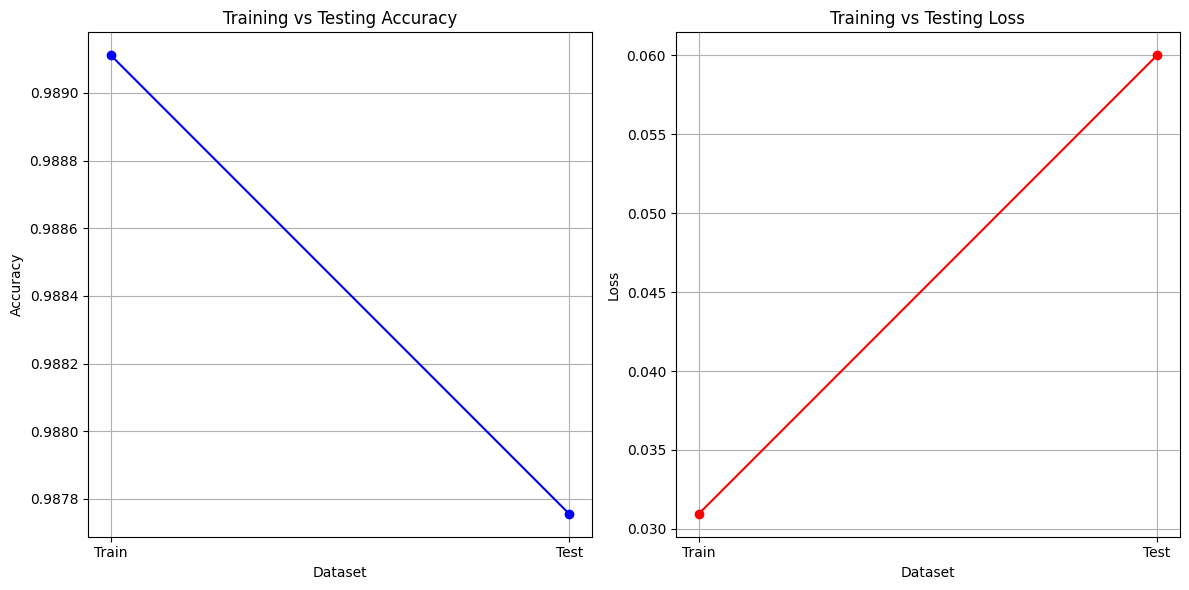

Unique classes in y_train_encoded: [0 1 2 3 4 5 6]
Unique classes in y_test_encoded: [0 1 2 3 4 5 6]
Unique classes in y_pred: [0 1 2 3 4 5 6]
Class distribution in y_train_encoded: [16343  4646  5441 25011 24702  4206 36930]
Class distribution in y_test_encoded: [4086 1161 1360 6253 6176 1052 9232]
Classification Report for XGBoost:
                     precision    recall  f1-score   support

       Mild Anxiety       1.00      0.99      0.99      4086
    Mild Depression       1.00      0.99      0.99      1161
   Moderate Anxiety       0.96      1.00      0.98      1360
Moderate Depression       1.00      0.97      0.99      6253
     Normal/Healthy       1.00      0.98      0.99      6176
     Severe Anxiety       0.90      0.99      0.94      1052
  Severe Depression       0.98      1.00      0.99      9232

           accuracy                           0.99     29320
          macro avg       0.98      0.99      0.98     29320
       weighted avg       0.99      0.99      0.99  

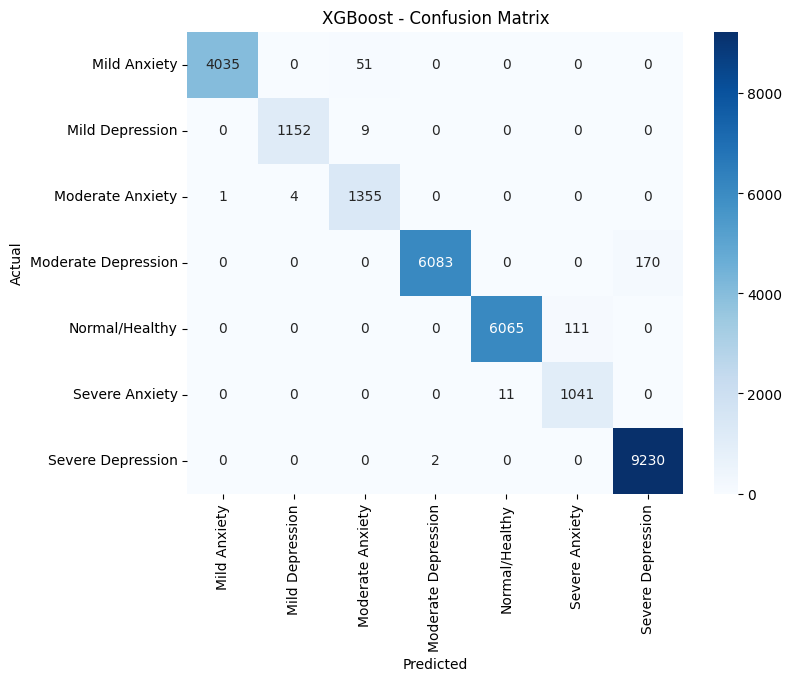

Training ROC AUC Score: 0.9998
Testing ROC AUC Score: 0.9981


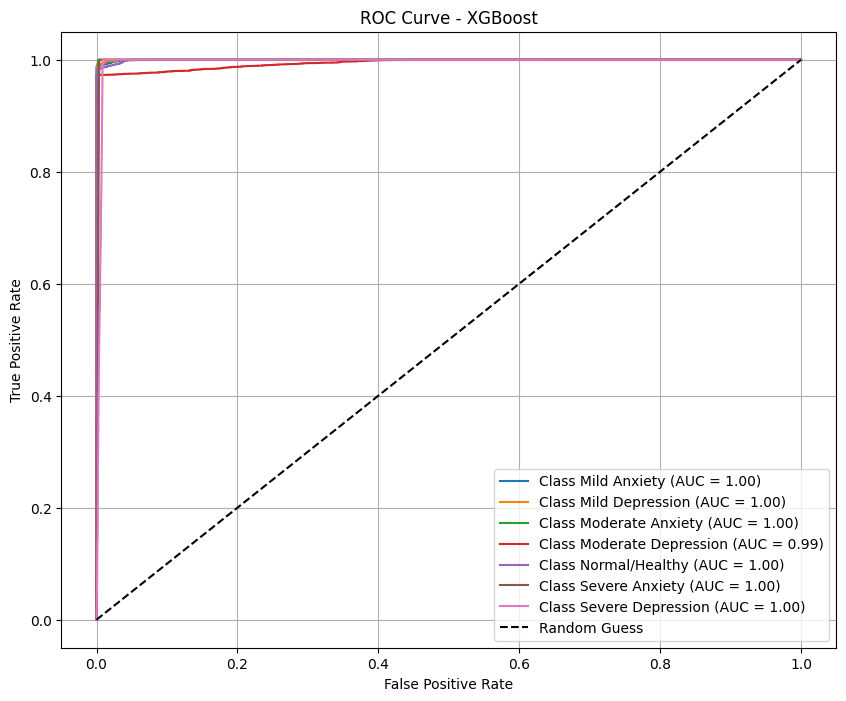

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, log_loss, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, and y_test are already available

# Encode the target classes
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # Encode the target classes
y_test_encoded = encoder.transform(y_test)

# If the 'Gender' column exists, we encode it
if 'Gender' in X_train.columns:
    X_train['Gender'] = encoder.fit_transform(X_train['Gender'])
    X_test['Gender'] = encoder.transform(X_test['Gender'])

# Scaling the numeric features (excluding categorical columns like 'Gender')
scaler = StandardScaler()
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Only scale numeric columns
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Convert the scaled features back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_columns)

# If the 'Gender' column was encoded, we add it back to the scaled features
if 'Gender' in X_train.columns:
    X_train_scaled['Gender'] = X_train['Gender'].values
    X_test_scaled['Gender'] = X_test['Gender'].values

# Initialize XGBoost model
model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Fit the model
model.fit(X_train_scaled, y_train_encoded)

# Make predictions and get probabilities
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_prob = model.predict_proba(X_train_scaled)
y_test_prob = model.predict_proba(X_test_scaled)

# Calculate training and testing metrics
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_loss = log_loss(y_train_encoded, y_train_prob)
test_loss = log_loss(y_test_encoded, y_test_prob)

# Display metrics
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

# Plot training and testing loss and accuracy curves
epochs = ['Train', 'Test']
accuracy_values = [train_accuracy, test_accuracy]
loss_values = [train_loss, test_loss]

plt.figure(figsize=(12, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy_values, marker='o', label='Accuracy', color='blue')
plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_values, marker='o', label='Loss', color='red')
plt.title("Training vs Testing Loss")
plt.xlabel("Dataset")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Check unique values in predictions
print("Unique classes in y_train_encoded:", np.unique(y_train_encoded))
print("Unique classes in y_test_encoded:", np.unique(y_test_encoded))
print("Unique classes in y_pred:", np.unique(y_test_pred))

# Class distribution in train and test sets
print("Class distribution in y_train_encoded:", np.bincount(y_train_encoded))
print("Class distribution in y_test_encoded:", np.bincount(y_test_encoded))

# Target names for classification report
target_names = ['Mild Anxiety', 'Mild Depression', 'Moderate Anxiety', 'Moderate Depression', 
                'Normal/Healthy', 'Severe Anxiety', 'Severe Depression']

# Evaluation
print("Classification Report for XGBoost:")
print(classification_report(y_test_encoded, y_test_pred, target_names=target_names, zero_division=0))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
train_roc_auc = roc_auc_score(y_train_encoded, y_train_prob, multi_class='ovr', average='macro')
test_roc_auc = roc_auc_score(y_test_encoded, y_test_prob, multi_class='ovr', average='macro')
print(f"Training ROC AUC Score: {train_roc_auc:.4f}")
print(f"Testing ROC AUC Score: {test_roc_auc:.4f}")

# Plot AUC Curve
plt.figure(figsize=(10, 8))
for i in range(y_test_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {target_names[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.grid()
plt.show()


In [24]:
import xgboost as xgb

# Train the XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_scaled, y_train)

# Save as .pkl
joblib.dump(xgb_model, "xgboost.pkl")

# Save as .h5
with h5py.File("xgboost_model.h5", "w") as hf:
    hf.create_dataset("model_data", data=joblib.dump(xgb_model, 'xgb_temp.pkl'))


MLP (Multilayer Perceptron)

Training Accuracy: 0.9868
Testing Accuracy: 0.9870
Training Loss: 0.0571
Testing Loss: 0.0608


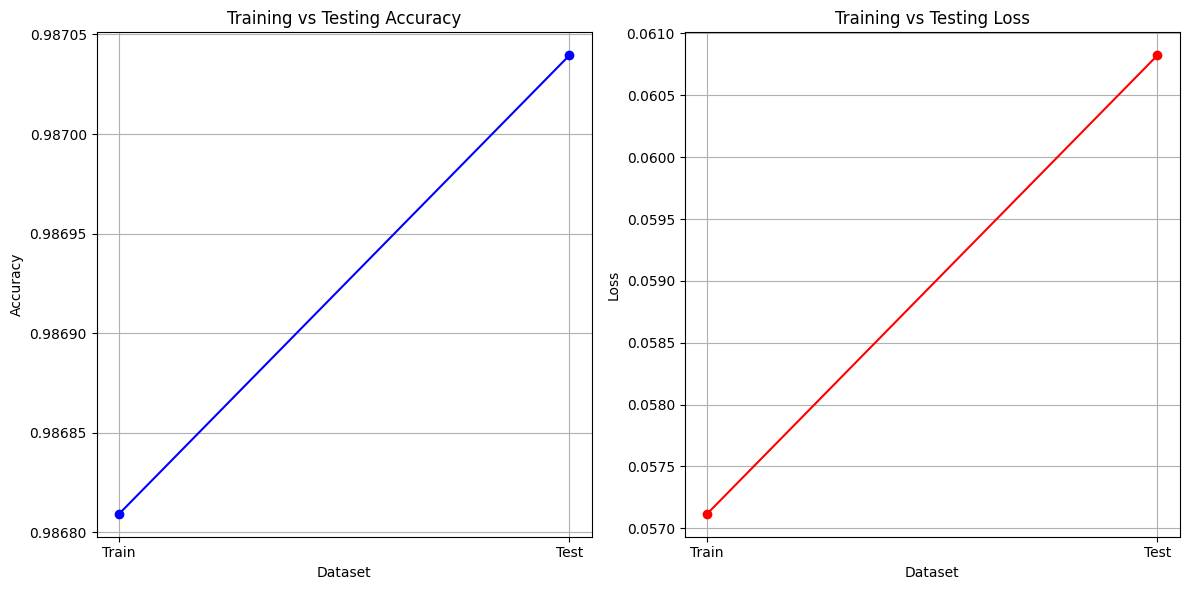

Unique classes in y_train_encoded: [0 1 2 3 4 5 6]
Unique classes in y_test_encoded: [0 1 2 3 4 5 6]
Unique classes in y_pred: [0 1 2 3 4 5 6]
Class distribution in y_train_encoded: [16343  4646  5441 25011 24702  4206 36930]
Class distribution in y_test_encoded: [4086 1161 1360 6253 6176 1052 9232]
Classification Report for MLP:
                     precision    recall  f1-score   support

       Mild Anxiety       1.00      0.99      0.99      4086
    Mild Depression       1.00      0.99      0.99      1161
   Moderate Anxiety       0.96      0.98      0.97      1360
Moderate Depression       1.00      0.97      0.99      6253
     Normal/Healthy       1.00      0.98      0.99      6176
     Severe Anxiety       0.90      0.99      0.95      1052
  Severe Depression       0.98      1.00      0.99      9232

           accuracy                           0.99     29320
          macro avg       0.98      0.99      0.98     29320
       weighted avg       0.99      0.99      0.99     2

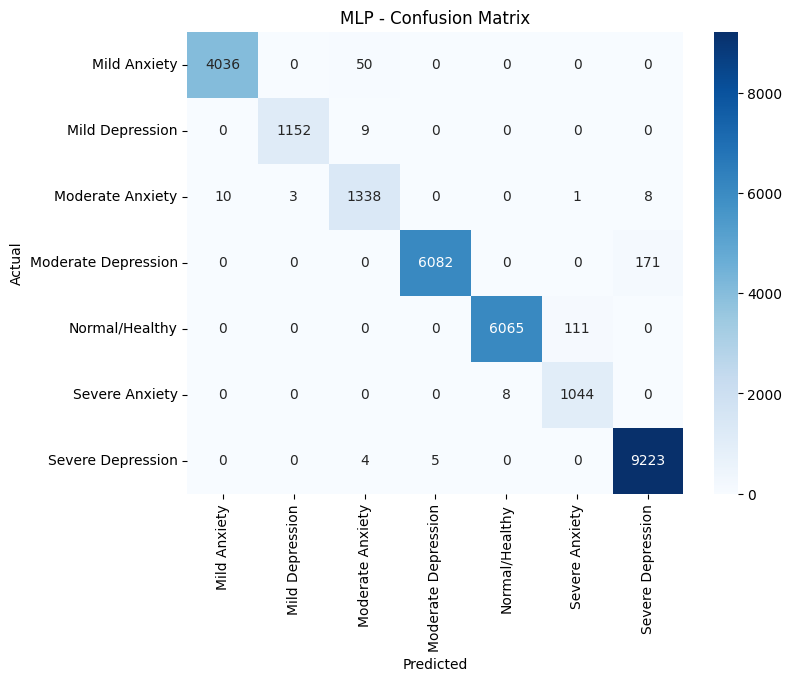

Training ROC AUC Score: 0.9985
Testing ROC AUC Score: 0.9980


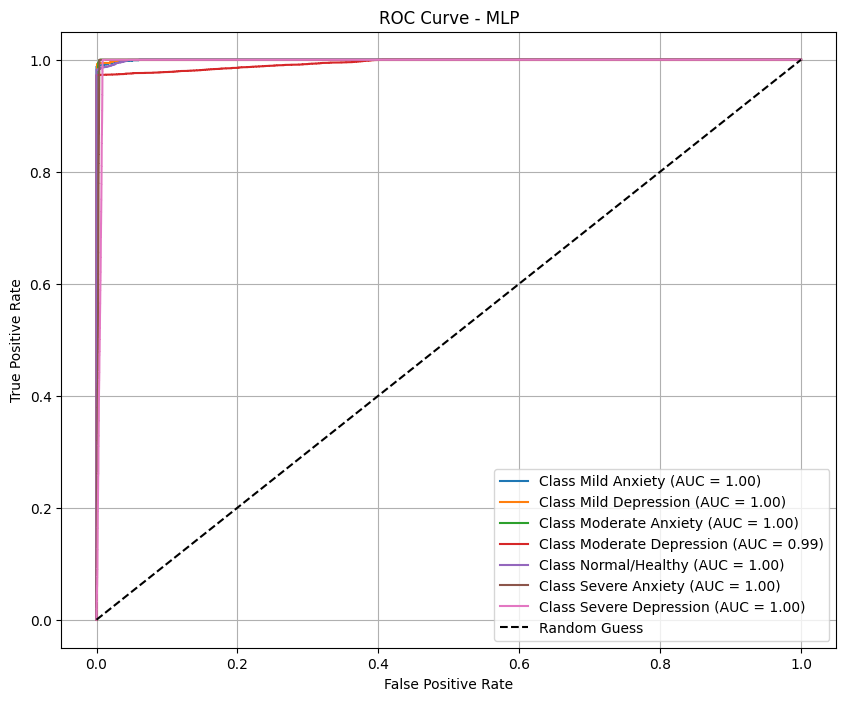

In [25]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, log_loss, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, and y_test are already available

# Encode the target classes
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # Encode the target classes
y_test_encoded = encoder.transform(y_test)

# If the 'Gender' column exists, we encode it
if 'Gender' in X_train.columns:
    X_train['Gender'] = encoder.fit_transform(X_train['Gender'])
    X_test['Gender'] = encoder.transform(X_test['Gender'])

# Scaling the numeric features (excluding categorical columns like 'Gender')
scaler = StandardScaler()
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Only scale numeric columns
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Convert the scaled features back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_columns)

# If the 'Gender' column was encoded, we add it back to the scaled features
if 'Gender' in X_train.columns:
    X_train_scaled['Gender'] = X_train['Gender'].values
    X_test_scaled['Gender'] = X_test['Gender'].values

# Initialize MLP model (Multilayer Perceptron)
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42, solver='adam', activation='relu')

# Fit the model
model.fit(X_train_scaled, y_train_encoded)

# Make predictions and get probabilities
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_prob = model.predict_proba(X_train_scaled)
y_test_prob = model.predict_proba(X_test_scaled)

# Calculate training and testing metrics
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_loss = log_loss(y_train_encoded, y_train_prob)
test_loss = log_loss(y_test_encoded, y_test_prob)

# Display metrics
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

# Plot training and testing loss and accuracy curves
epochs = ['Train', 'Test']
accuracy_values = [train_accuracy, test_accuracy]
loss_values = [train_loss, test_loss]

plt.figure(figsize=(12, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy_values, marker='o', label='Accuracy', color='blue')
plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_values, marker='o', label='Loss', color='red')
plt.title("Training vs Testing Loss")
plt.xlabel("Dataset")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# Check unique values in predictions
print("Unique classes in y_train_encoded:", np.unique(y_train_encoded))
print("Unique classes in y_test_encoded:", np.unique(y_test_encoded))
print("Unique classes in y_pred:", np.unique(y_test_pred))

# Class distribution in train and test sets
print("Class distribution in y_train_encoded:", np.bincount(y_train_encoded))
print("Class distribution in y_test_encoded:", np.bincount(y_test_encoded))

# Target names for classification report
target_names = ['Mild Anxiety', 'Mild Depression', 'Moderate Anxiety', 'Moderate Depression', 
                'Normal/Healthy', 'Severe Anxiety', 'Severe Depression']

# Evaluation
print("Classification Report for MLP:")
print(classification_report(y_test_encoded, y_test_pred, target_names=target_names, zero_division=0))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
train_roc_auc = roc_auc_score(y_train_encoded, y_train_prob, multi_class='ovr', average='macro')
test_roc_auc = roc_auc_score(y_test_encoded, y_test_prob, multi_class='ovr', average='macro')
print(f"Training ROC AUC Score: {train_roc_auc:.4f}")
print(f"Testing ROC AUC Score: {test_roc_auc:.4f}")

# Plot AUC Curve
plt.figure(figsize=(10, 8))
for i in range(y_test_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {target_names[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - MLP")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.grid()
plt.show()


In [26]:
from sklearn.neural_network import MLPClassifier

# Train the MLP model
mlp_model = MLPClassifier()
mlp_model.fit(X_train_scaled, y_train)

# Save as .pkl
joblib.dump(mlp_model, "mlp.pkl")

# Save as .h5
with h5py.File("mlp_model.h5", "w") as hf:
    hf.create_dataset("model_data", data=joblib.dump(mlp_model, 'mlp_temp.pkl'))


Best 4 DL MODELS

Deeper Neural Network

Epoch 1/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8459 - loss: 0.4837 - val_accuracy: 0.9782 - val_loss: 0.0878
Epoch 2/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 952us/step - accuracy: 0.9641 - loss: 0.1312 - val_accuracy: 0.9821 - val_loss: 0.0721
Epoch 3/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 982us/step - accuracy: 0.9746 - loss: 0.0999 - val_accuracy: 0.9841 - val_loss: 0.0645
Epoch 4/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 995us/step - accuracy: 0.9773 - loss: 0.0897 - val_accuracy: 0.9845 - val_loss: 0.0646
Epoch 5/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 982us/step - accuracy: 0.9788 - loss: 0.0858 - val_accuracy: 0.9845 - val_loss: 0.0615
Epoch 6/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 990us/step - accuracy: 0.9787 - loss: 0.0836 - val_accuracy: 0.9857 - val_loss: 0.0595
Epoch 7/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 967us/step - accuracy: 0.9805 - loss: 0.0786 - val_accuracy: 0.9854 - val_loss: 0.0606
Epoch 8/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 4s 978us/step - accuracy: 0.9809 - l

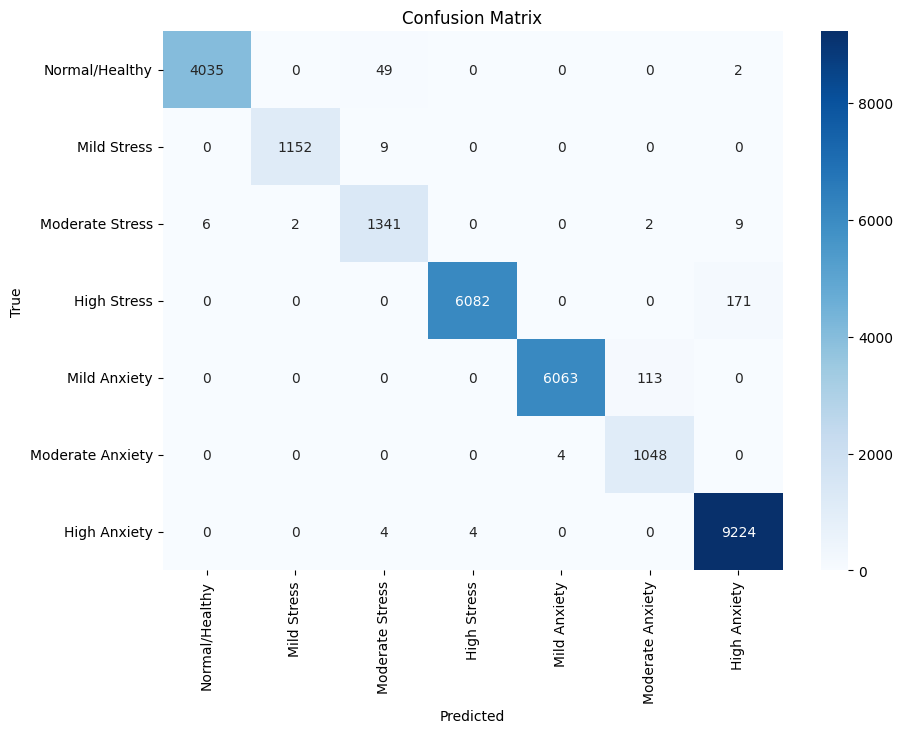

917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 591us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 642us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 604us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 597us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step


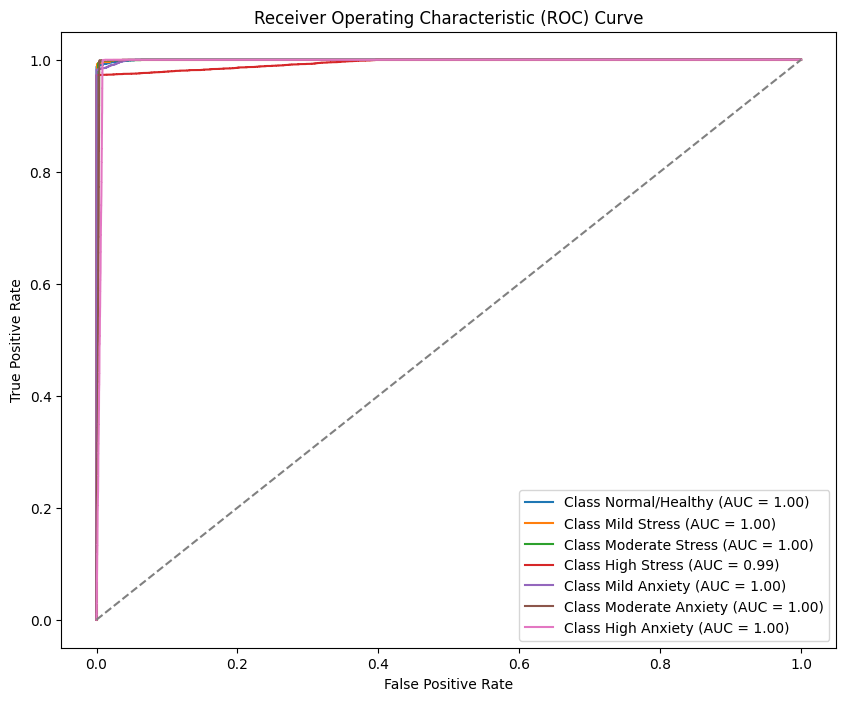

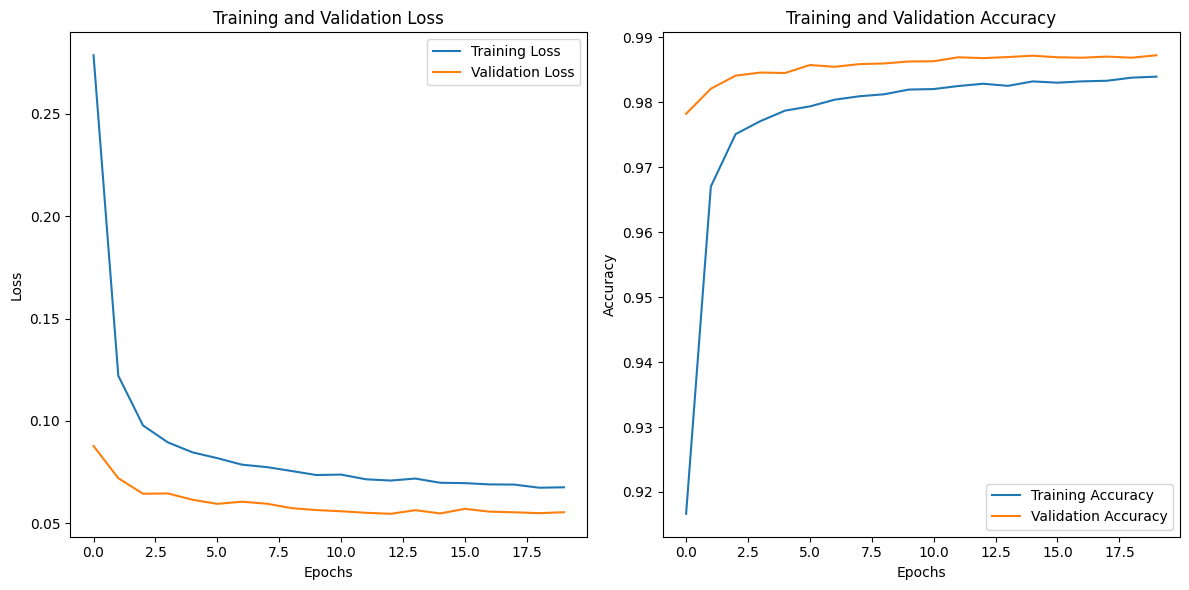

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np

# Ensure you have already preprocessed the data and have the variables:
# X_train_scaled, y_train, X_test_scaled, y_test

# One-hot encode the target labels
y_train_onehot = to_categorical(y_train, num_classes=len(np.unique(y_train)))
y_test_onehot = to_categorical(y_test, num_classes=len(np.unique(y_test)))

# Check the number of unique classes in y_train and y_test
class_names = ["Normal/Healthy", "Mild Stress", "Moderate Stress", "High Stress", 
               "Mild Anxiety", "Moderate Anxiety", "High Anxiety"]  # Modify this as per your classes

# Define the Deep Neural Network (DNN) Model
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # Input layer based on the number of features
    Dense(128, activation='relu'),  # First hidden layer
    Dropout(0.3),  # Dropout for regularization
    Dense(64, activation='relu'),  # Second hidden layer
    Dropout(0.3),
    Dense(32, activation='relu'),  # Third hidden layer
    Dropout(0.3),
    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer with softmax
])

# Compile the model
dnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = dnn_model.fit(X_train_scaled, y_train_onehot, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test_onehot))

# Predict using the trained model
y_pred_dnn = np.argmax(dnn_model.predict(X_test_scaled), axis=1)

# Classification Report
print("Classification Report for DNN:\n", classification_report(np.argmax(y_test_onehot, axis=1), y_pred_dnn, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(np.argmax(y_test_onehot, axis=1), y_pred_dnn)

# Plot Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve (One per class)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_onehot[:, i], dnn_model.predict(X_test_scaled)[:, i])
    roc_auc[i] = roc_auc_score(y_test_onehot[:, i], dnn_model.predict(X_test_scaled)[:, i])

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Plot Training and Testing Loss/Accuracy
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define and train a DNN model
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(len(set(y_train)), activation='softmax')  # Output layer
])
dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
dnn_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

# Save as .h5
dnn_model.save("dnn_model.h5")


Epoch 1/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 678us/step - accuracy: 0.9261 - loss: 0.2792
Epoch 2/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 699us/step - accuracy: 0.9811 - loss: 0.0779
Epoch 3/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 712us/step - accuracy: 0.9839 - loss: 0.0685
Epoch 4/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 705us/step - accuracy: 0.9858 - loss: 0.0628
Epoch 5/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 692us/step - accuracy: 0.9865 - loss: 0.0583
Epoch 6/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 708us/step - accuracy: 0.9866 - loss: 0.0581
Epoch 7/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 2s 627us/step - accuracy: 0.9868 - loss: 0.0568
Epoch 8/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 680us/step - accuracy: 0.9868 - loss: 0.0568
Epoch 9/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 711us/step - accuracy: 0.9870 - loss: 0.0562
Epoch 10/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 3s 684us/step - accuracy: 0.9871 - loss: 0.0556


LSTM Model

Epoch 1/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.6949 - loss: 0.8586 - val_accuracy: 0.9677 - val_loss: 0.1242
Epoch 2/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9590 - loss: 0.1509 - val_accuracy: 0.9833 - val_loss: 0.0716
Epoch 3/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9757 - loss: 0.1015 - val_accuracy: 0.9827 - val_loss: 0.0707
Epoch 4/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9802 - loss: 0.0836 - val_accuracy: 0.9844 - val_loss: 0.0679
Epoch 5/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9829 - loss: 0.0751 - val_accuracy: 0.9872 - val_loss: 0.0563
Epoch 6/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9840 - loss: 0.0706 - val_accuracy: 0.9859 - val_loss: 0.0581
Epoch 7/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9844 - loss: 0.0679 - val_accuracy: 0.9872 - val_loss: 0.0551
Epoch 8/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9849 - loss: 0

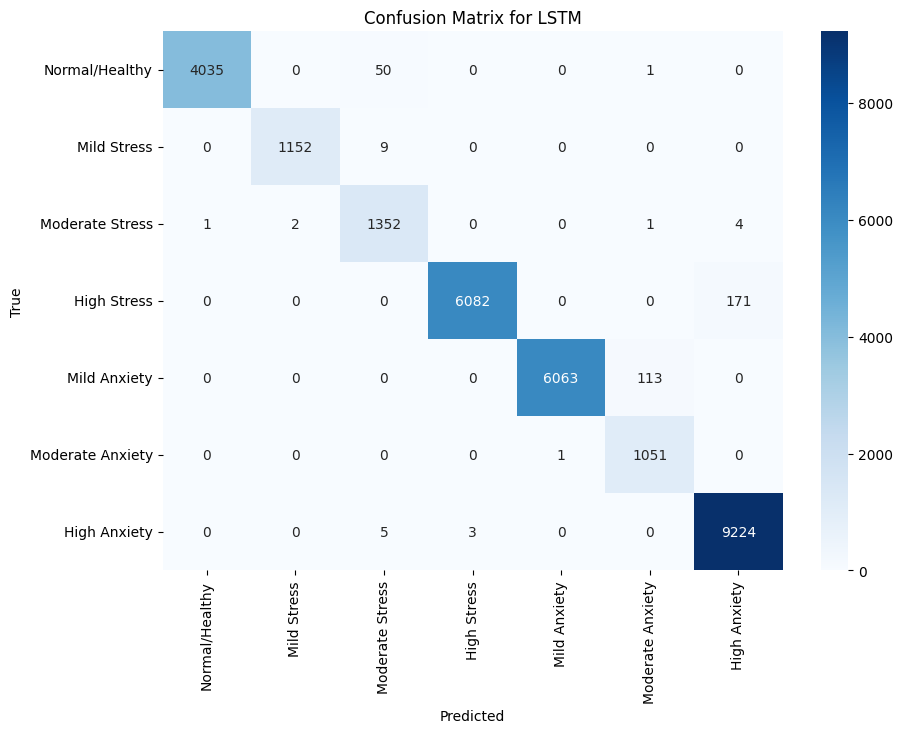

917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


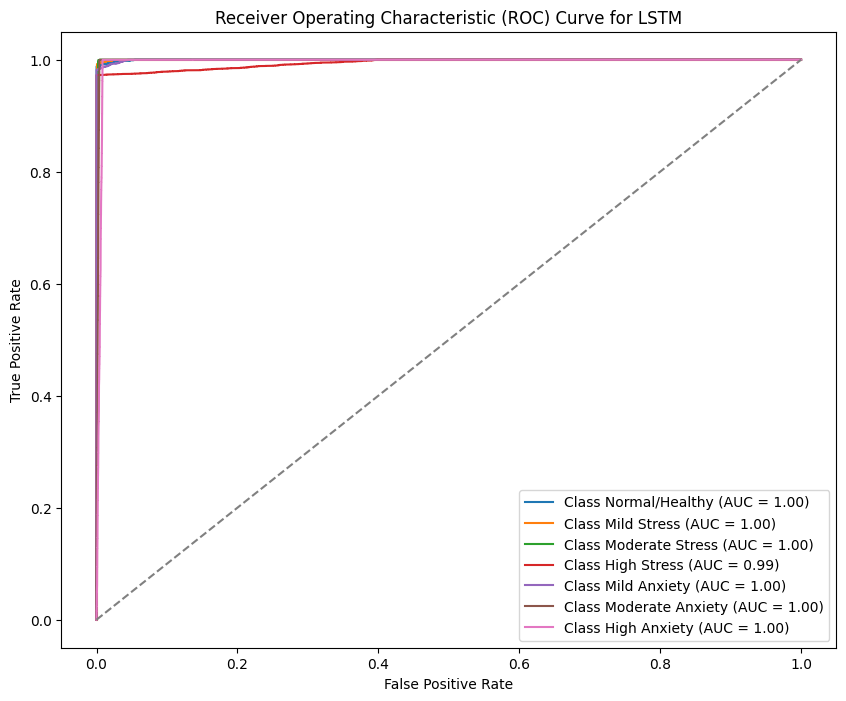

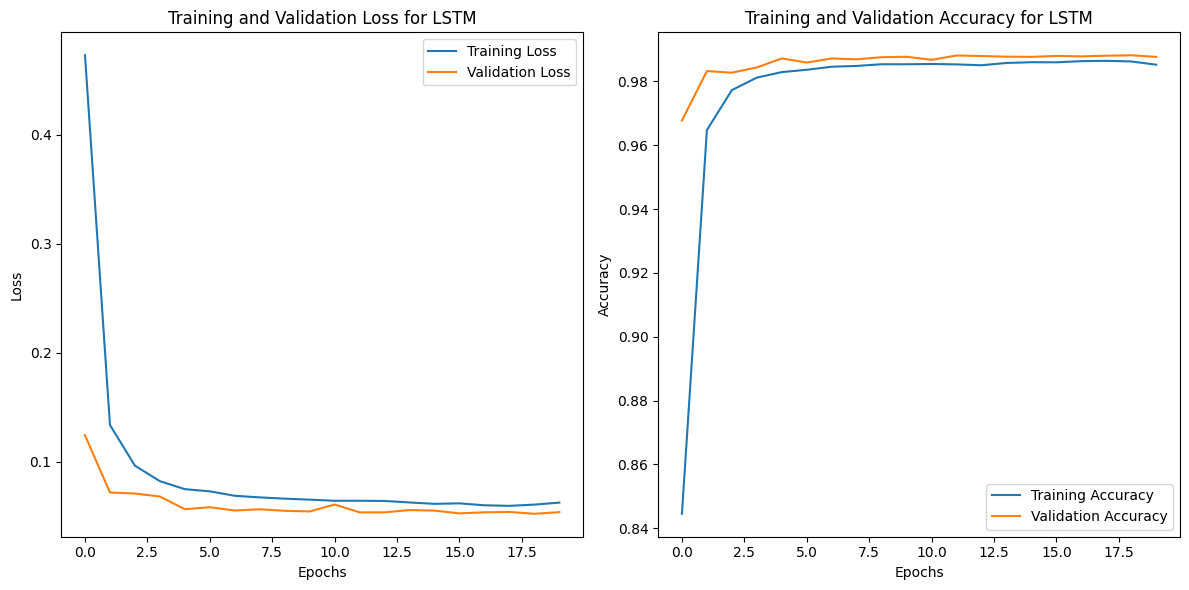

In [29]:
from tensorflow.keras.layers import LSTM

# Define the LSTM Model
lstm_model = Sequential([
    Input(shape=(X_train_scaled.shape[1], 1)),  # Reshape input for LSTM (requires 3D input)
    LSTM(128, activation='relu', return_sequences=True),  # LSTM layer
    Dropout(0.3),
    LSTM(64, activation='relu'),  # Second LSTM layer
    Dropout(0.3),
    Dense(32, activation='relu'),  # Dense layer after LSTM layers
    Dropout(0.3),
    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer with softmax
])

# Reshape the input data to 3D for LSTM
X_train_scaled_3d = np.expand_dims(X_train_scaled, axis=-1)
X_test_scaled_3d = np.expand_dims(X_test_scaled, axis=-1)

# Compile the model
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history_lstm = lstm_model.fit(X_train_scaled_3d, y_train_onehot, epochs=20, batch_size=32, validation_data=(X_test_scaled_3d, y_test_onehot))

# Predict using the trained model
y_pred_lstm = np.argmax(lstm_model.predict(X_test_scaled_3d), axis=1)

# Classification Report
print("Classification Report for LSTM:\n", classification_report(np.argmax(y_test_onehot, axis=1), y_pred_lstm, target_names=class_names))

# Confusion Matrix
cm_lstm = confusion_matrix(np.argmax(y_test_onehot, axis=1), y_pred_lstm)

# Plot Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for LSTM')
plt.show()

# ROC Curve (One per class)
fpr_lstm, tpr_lstm, roc_auc_lstm = {}, {}, {}
for i in range(len(class_names)):
    fpr_lstm[i], tpr_lstm[i], _ = roc_curve(y_test_onehot[:, i], lstm_model.predict(X_test_scaled_3d)[:, i])
    roc_auc_lstm[i] = roc_auc_score(y_test_onehot[:, i], lstm_model.predict(X_test_scaled_3d)[:, i])

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    plt.plot(fpr_lstm[i], tpr_lstm[i], label=f'Class {class_names[i]} (AUC = {roc_auc_lstm[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for LSTM')
plt.legend(loc='lower right')
plt.show()

# Plot Training and Testing Loss/Accuracy
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy for LSTM')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define and train an LSTM model
lstm_model = Sequential([
    
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    LSTM(32, activation='tanh'),
    Dense(len(set(y_train)), activation='softmax')  # Output layer
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

# Save as .keras (native Keras format)
lstm_model.save("lstm_model.keras")


Epoch 1/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7781 - loss: 0.6674
Epoch 2/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9278 - loss: 0.2371
Epoch 3/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9748 - loss: 0.0972
Epoch 4/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9823 - loss: 0.0746
Epoch 5/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9848 - loss: 0.0647
Epoch 6/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9853 - loss: 0.0630
Epoch 7/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9866 - loss: 0.0584
Epoch 8/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9860 - loss: 0.0592
Epoch 9/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9866 - loss: 0.0573
Epoch 10/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9865 - loss: 0.0570


GRU Model

Epoch 1/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8685 - loss: 0.4353 - val_accuracy: 0.9794 - val_loss: 0.0852
Epoch 2/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9661 - loss: 0.1282 - val_accuracy: 0.9823 - val_loss: 0.0712
Epoch 3/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9726 - loss: 0.1100 - val_accuracy: 0.9818 - val_loss: 0.0676
Epoch 4/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9753 - loss: 0.0979 - val_accuracy: 0.9821 - val_loss: 0.0665
Epoch 5/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9750 - loss: 0.0976 - val_accuracy: 0.9831 - val_loss: 0.0651
Epoch 6/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9768 - loss: 0.0942 - val_accuracy: 0.9849 - val_loss: 0.0622
Epoch 7/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9790 - loss: 0.0856 - val_accuracy: 0.9854 - val_loss: 0.0591
Epoch 8/20
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9793 - loss: 0.0848 - 

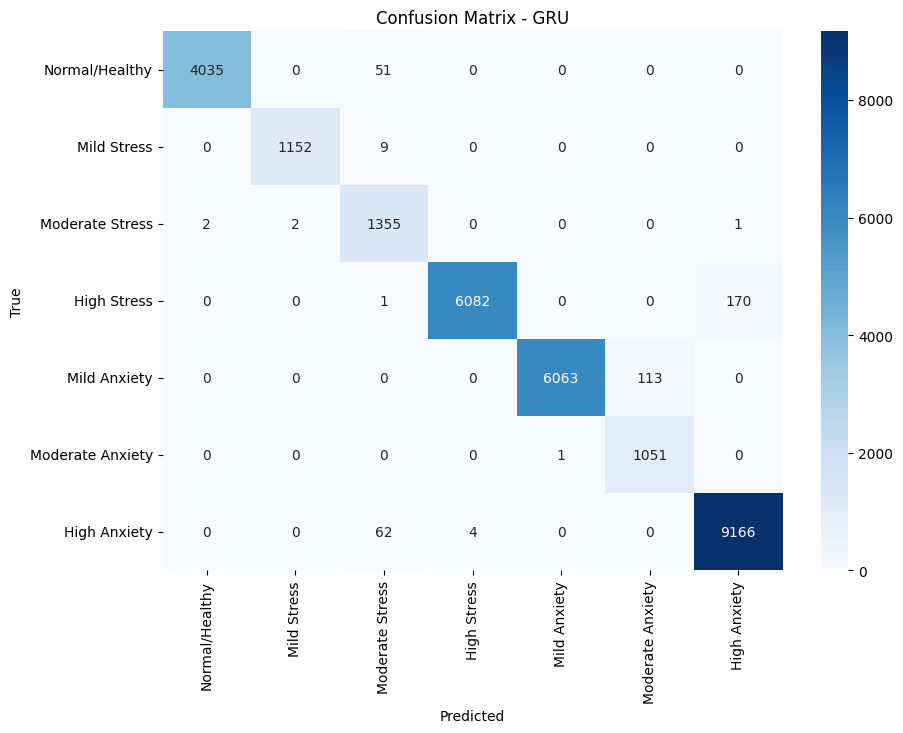

917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step
917/917 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step


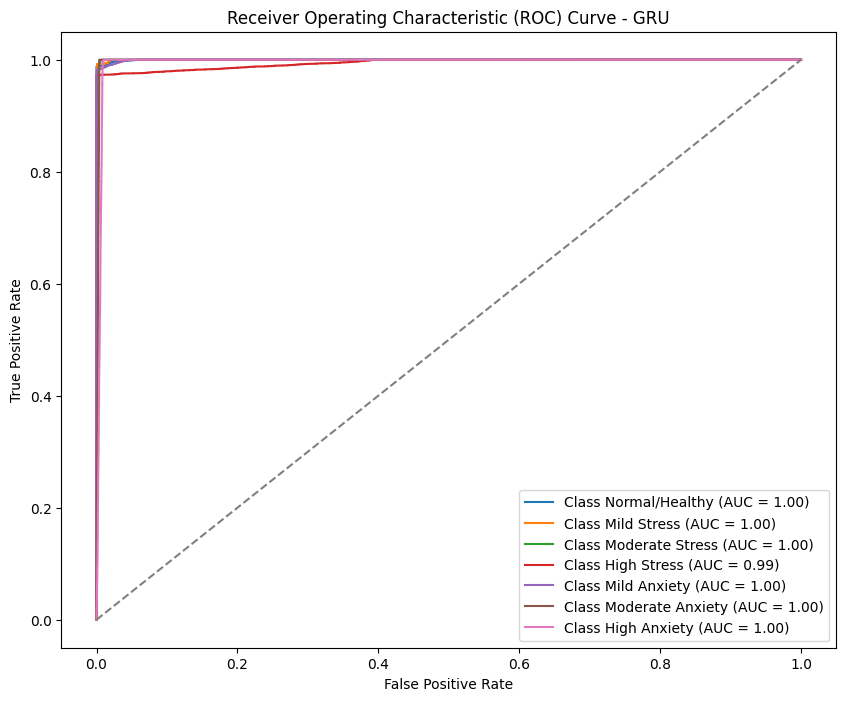

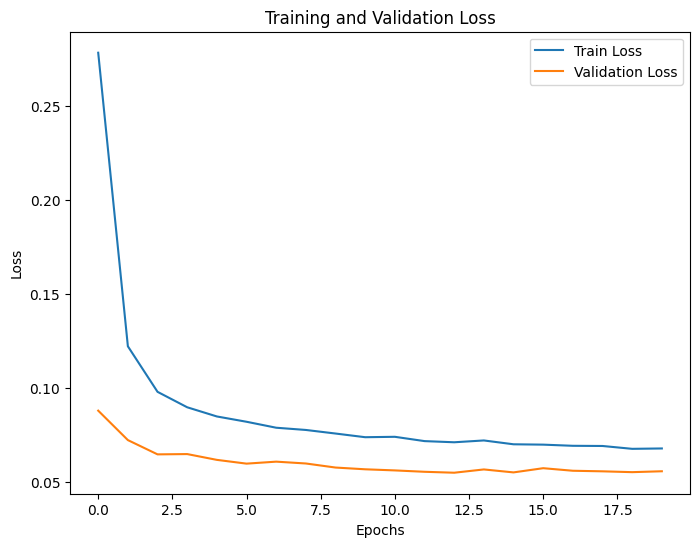

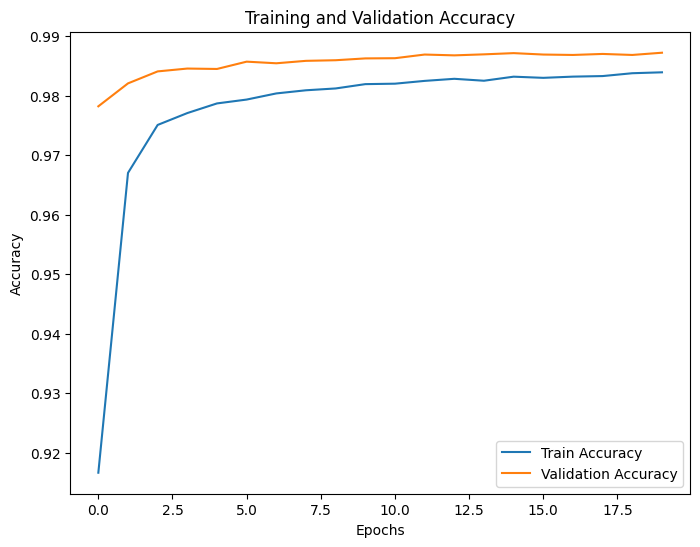

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

# Ensure you have already preprocessed the data and have the variables:
# X_train_scaled, y_train, X_test_scaled, y_test

# One-hot encode the target labels
y_train_onehot = to_categorical(y_train, num_classes=len(np.unique(y_train)))
y_test_onehot = to_categorical(y_test, num_classes=len(np.unique(y_test)))

# Convert DataFrame to numpy array before reshaping
X_train_gru = X_train_scaled.values.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))  # (samples, time_steps=1, features)
X_test_gru = X_test_scaled.values.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))  # (samples, time_steps=1, features)

# Define the GRU Model
gru_model = Sequential([
    Input(shape=(X_train_gru.shape[1], X_train_gru.shape[2])),  # Input shape for GRU
    GRU(64, activation='relu', return_sequences=True),  # GRU layer
    BatchNormalization(),
    Dropout(0.3),
    GRU(32, activation='relu', return_sequences=False),  # Second GRU layer
    BatchNormalization(),
    Dropout(0.3),
    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer
])

# Compile the model
gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the GRU Model
history_gru = gru_model.fit(X_train_gru, y_train_onehot, epochs=20, batch_size=32, validation_data=(X_test_gru, y_test_onehot))

# Predict using the trained model
y_pred_gru = np.argmax(gru_model.predict(X_test_gru), axis=1)

# Classification Report
print("Classification Report for GRU:\n", classification_report(np.argmax(y_test_onehot, axis=1), y_pred_gru, target_names=class_names))

# Confusion Matrix
cm_gru = confusion_matrix(np.argmax(y_test_onehot, axis=1), y_pred_gru)

# Plot Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - GRU')
plt.show()

# ROC Curve (One per class)
fpr_gru, tpr_gru, roc_auc_gru = {}, {}, {}
for i in range(len(class_names)):
    fpr_gru[i], tpr_gru[i], _ = roc_curve(y_test_onehot[:, i], gru_model.predict(X_test_gru)[:, i])
    roc_auc_gru[i] = roc_auc_score(y_test_onehot[:, i], gru_model.predict(X_test_gru)[:, i])

# Plot ROC Curves for GRU
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    plt.plot(fpr_gru[i], tpr_gru[i], label=f'Class {class_names[i]} (AUC = {roc_auc_gru[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - GRU')
plt.legend(loc='lower right')
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training & validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Define and train a GRU model
gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    GRU(32, activation='tanh'),
    Dense(len(set(y_train)), activation='softmax')  # Output layer
])
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

# Save as .keras (native Keras format)
gru_model.save("gru_model.keras")


Epoch 1/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8619 - loss: 0.4207
Epoch 2/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9842 - loss: 0.0677
Epoch 3/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9858 - loss: 0.0606
Epoch 4/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9856 - loss: 0.0612
Epoch 5/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9868 - loss: 0.0571
Epoch 6/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9869 - loss: 0.0566
Epoch 7/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9867 - loss: 0.0573
Epoch 8/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9869 - loss: 0.0556
Epoch 9/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9872 - loss: 0.0546
Epoch 10/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9871 - loss: 0.0557


LSTM with Batch Normalization Network

Epoch 1/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8656 - loss: 0.4484 - val_accuracy: 0.9756 - val_loss: 0.0930
Epoch 2/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9658 - loss: 0.1291 - val_accuracy: 0.9817 - val_loss: 0.0736
Epoch 3/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9755 - loss: 0.0996 - val_accuracy: 0.9843 - val_loss: 0.0648
Epoch 4/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9783 - loss: 0.0875 - val_accuracy: 0.9859 - val_loss: 0.0597
Epoch 5/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9813 - loss: 0.0795 - val_accuracy: 0.9862 - val_loss: 0.0578
Epoch 6/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9818 - loss: 0.0769 - val_accuracy: 0.9863 - val_loss: 0.0577
Epoch 7/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0754 - val_accuracy: 0.9863 - val_loss: 0.0567
Epoch 8/20
1833/1833 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9830 - loss: 0.0736 - 

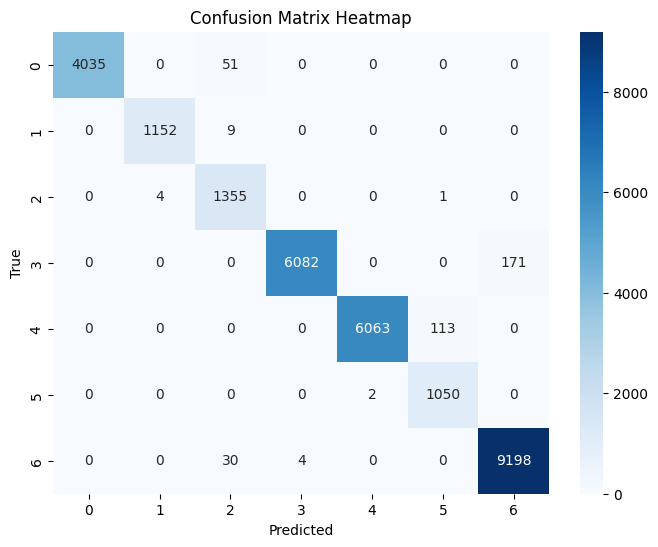

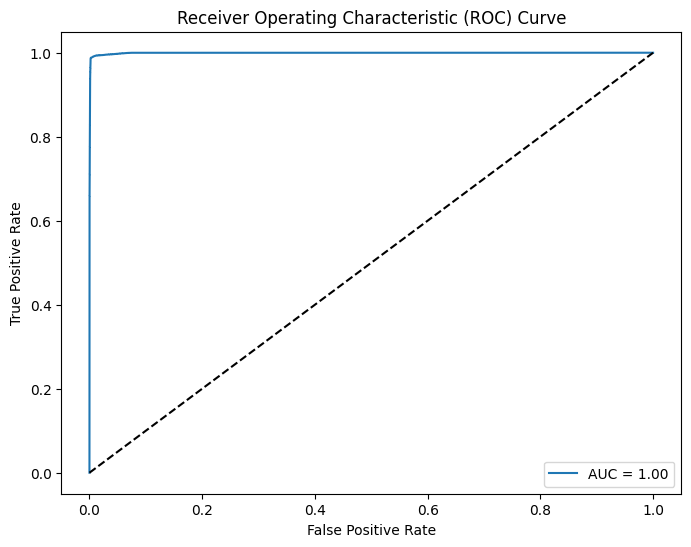

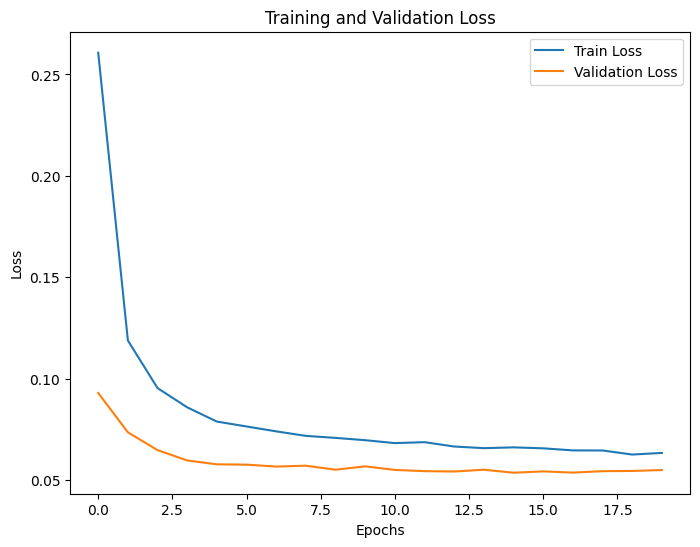

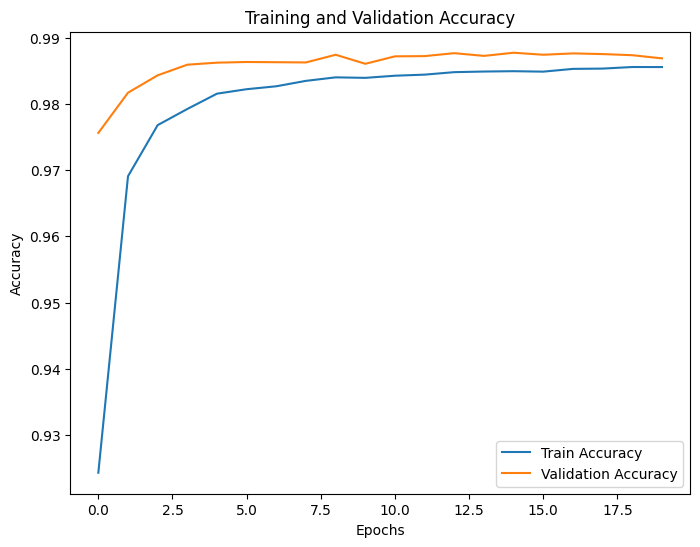

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from keras.models import Sequential
from keras.layers import LSTM, Dense, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.utils import to_categorical

# Assuming you have preprocessed your data
# X_train_scaled, X_test_scaled, y_train, y_test from previous steps

# Convert DataFrame to numpy array before reshaping
X_train_lstm = X_train_scaled.values.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])  # (samples, time_steps=1, features)
X_test_lstm = X_test_scaled.values.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])  # (samples, time_steps=1, features)

# Define the LSTM model with Batch Normalization
model = Sequential()

# Add LSTM layer with Batch Normalization
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Add Dense output layer with 7 classes (update from 10 to 7)
model.add(Dense(7, activation='softmax'))  # Adjust output units based on the number of classes

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_lstm, to_categorical(y_train), epochs=20, batch_size=64, validation_data=(X_test_lstm, to_categorical(y_test)))

# Evaluate the model
y_pred = model.predict(X_test_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(7), yticklabels=np.arange(7))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

# AUC Curve
y_test_ohe = to_categorical(y_test, num_classes=7)  # Ensure y_test is one-hot encoded with 7 classes
roc_auc = roc_auc_score(y_test_ohe, y_pred, multi_class='ovr')
fpr, tpr, _ = roc_curve(y_test_ohe.ravel(), y_pred.ravel())

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training & validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization

# Define and train an LSTM with Batch Normalization model
lstm_bn_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train_scaled.shape[1], 1)),
    BatchNormalization(),
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dense(len(set(y_train)), activation='softmax')  # Output layer
])
lstm_bn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_bn_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

# Save as .keras (native Keras format)
lstm_bn_model.save("lstm_bn_model.keras")


Epoch 1/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8894 - loss: 0.3725
Epoch 2/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9793 - loss: 0.0865
Epoch 3/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9828 - loss: 0.0735
Epoch 4/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9848 - loss: 0.0676
Epoch 5/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9851 - loss: 0.0659
Epoch 6/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9860 - loss: 0.0616
Epoch 7/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9862 - loss: 0.0614
Epoch 8/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9861 - loss: 0.0613
Epoch 9/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9864 - loss: 0.0602
Epoch 10/10
3665/3665 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9874 - loss: 0.0566


Loading the Saved Models

For ML and DL Models 

In [35]:
from tensorflow.keras.models import load_model


In [36]:
import joblib
import h5py
from tensorflow.keras.models import load_model

# Load Random Forest
rf_model = joblib.load("random_forest.pkl")

# Load Gradient Boosting
gb_model = joblib.load("gradient_boosting.pkl")

# Load XGBoost
xgb_model = joblib.load("xgboost.pkl")

# Load MLP
mlp_model = joblib.load("mlp.pkl")

# Load from .h5 (for Keras models)
lstm_model = load_model("lstm_model.keras")
gru_model = load_model("gru_model.keras")
lstm_bn_model = load_model("lstm_bn_model.keras")
dnn_model = load_model("dnn_model.h5")


For DL Models

In [37]:
from tensorflow.keras.optimizers import Adam

# Load Keras models
lstm_model = load_model("lstm_model.keras")
gru_model = load_model("gru_model.keras")
lstm_bn_model = load_model("lstm_bn_model.keras")
dnn_model = load_model("dnn_model.h5")

# Recompile the models
lstm_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_bn_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
dnn_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


 Integration with a Deployment Framework

 Deployment 

In [38]:
pip install gradio


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from sklearn.preprocessing import StandardScaler
import joblib

# Fit the scaler on training data (X_train should be the features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [40]:
import gradio as gr
import joblib
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import tensorflow as tf

# Updated Mental Health Class Labels (7 classes as per your dataset)
mental_health_classes = [
    'Mild Anxiety', 'Mild Depression', 'Moderate Anxiety', 'Moderate Depression', 
    'Normal/Healthy', 'Severe Anxiety', 'Severe Depression'
]

# Load models
rf_model = joblib.load("random_forest.pkl")
gb_model = joblib.load("gradient_boosting.pkl")
xgb_model = joblib.load("xgboost.pkl")
mlp_model = joblib.load("mlp.pkl")  # MLP model is loaded using joblib
lstm_model = load_model("lstm_model.keras", compile=False)  # LSTM model
gru_model = load_model("gru_model.keras", compile=False)  # GRU model
lstm_bn_model = load_model("lstm_bn_model.keras", compile=False)  # LSTM with Batch Normalization model
dnn_model = load_model("dnn_model.h5", compile=False)  # DNN model

# Load scaler for feature scaling
scaler = joblib.load('scaler.pkl')

# Function to clean input data (handle missing or empty values)
def clean_data(features):
    features = np.array(features, dtype=str)  # Ensure that the array is of type string initially
    features[features == ''] = np.nan  # Replace empty strings with NaN
    
    features_df = pd.DataFrame(features, columns=["Age", "Technology_Usage_Hours", "Social_Media_Usage_Hours", 
                                                  "Screen_Time_Hours", "Sleep_Hours", "Physical_Activity_Hours"])
    
    features_df = features_df.apply(pd.to_numeric, errors='coerce')  # Convert to numeric, invalid parsing will become NaN
    features_df = features_df.fillna(features_df.mean())  # Fill NaNs with the mean value of the column
    
    return features_df.values

# Define prediction functions for each model
def predict_rf(features):
    features_cleaned = clean_data(features)
    features_scaled = scaler.transform(features_cleaned)  # Apply scaling directly here
    prediction = rf_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[prediction[0]]}"

def predict_gb(features):
    features_cleaned = clean_data(features)
    features_scaled = scaler.transform(features_cleaned)  # Apply scaling directly here
    prediction = gb_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[prediction[0]]}"

def predict_xgb(features):
    features_cleaned = clean_data(features)
    features_scaled = scaler.transform(features_cleaned)  # Apply scaling directly here
    prediction = xgb_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[prediction[0]]}"

def predict_mlp(features):
    features_cleaned = clean_data(features)
    features_scaled = scaler.transform(features_cleaned)  # Apply scaling directly here
    prediction = mlp_model.predict(features_scaled)  # Using joblib model
    return f"Prediction: {mental_health_classes[prediction[0]]}"

# Define the model prediction functions for LSTM, GRU, and DNN
def predict_lstm(features):
    features = np.array(features, dtype=float).reshape(1, -1)  # Ensure features are in correct shape
    features_scaled = scaler.transform(features)
    prediction = lstm_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[np.argmax(prediction)]}"

def predict_gru(features):
    features = np.array(features, dtype=float).reshape(1, -1)  # Ensure features are in correct shape
    features_scaled = scaler.transform(features)
    prediction = gru_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[np.argmax(prediction)]}"

def predict_lstm_bn(features):
    features = np.array(features, dtype=float).reshape(1, -1)  # Ensure features are in correct shape
    features_scaled = scaler.transform(features)
    features_reshaped = features_scaled.reshape(1, 1, -1)  # Reshape for LSTM input
    prediction = lstm_bn_model.predict(features_reshaped)
    return f"Prediction: {mental_health_classes[np.argmax(prediction)]}"

def predict_dnn(features):
    features_cleaned = clean_data(features)
    features_scaled = scaler.transform(features_cleaned)  # Apply scaling directly here
    prediction = dnn_model.predict(features_scaled)
    return f"Prediction: {mental_health_classes[np.argmax(prediction)]}"

# Create the Gradio interface
def model_selector(model_name, features):
    
    if model_name == "Random Forest":
        return predict_rf(features)
    elif model_name == "Gradient Boosting":
        return predict_gb(features)
    elif model_name == "XGBoost":
        return predict_xgb(features)
    elif model_name == "MLP":
        return predict_mlp(features)
    elif model_name == "LSTM":
        return predict_lstm(features)
    elif model_name == "GRU":
        return predict_gru(features)
    elif model_name == "LSTM with Batch Normalization":
        return predict_lstm_bn(features)
    elif model_name == "DNN":
        return predict_dnn(features)

# Define the Gradio interface with a dropdown for model selection
interface = gr.Interface(
    fn=model_selector,
    inputs=[
        gr.Dropdown(
            choices=["Random Forest", "Gradient Boosting", "XGBoost", "MLP", "LSTM", "GRU", 
                     "LSTM with Batch Normalization", "DNN"],
            label="Select Model"
        ),
        gr.Dataframe(
            headers=["Age", "Technology_Usage_Hours", "Social_Media_Usage_Hours", 
                     "Screen_Time_Hours", "Sleep_Hours", "Physical_Activity_Hours"],
            row_count=1,
            col_count=6,
            label="Input Features",
            interactive=True  # Ensure input features are editable
        )
    ],
    outputs="text",
    live=False  # Set live=False to prevent output before entering values
)

# Launch the interface
interface.launch()


* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


In [41]:

interface.launch(share=True)  # This enables a public URL for mobile access


Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* Running on public URL: https://9c86475604f4b9f4d7.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
